# 01 — Exploratory diagnostics for H1

**Status: exploratory.** Nothing here is a formal test of H1. The specification (windows,
variants, exclusion rule, events, eras) was frozen in
`docs/decisions/0004-h1-exploratory-specification.md` before any of these results were
computed. Any specification added after seeing them is labelled *post-hoc* below.

All computation lives in `src/kagura/explore.py`; this notebook only calls it and records notes.
Re-run from the repo root with:

```bash
make data   # only if data/processed is missing or stale
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/01_exploration.ipynb
```
Figures are also written to `reports/figures/`.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

from kagura import explore as ex
from kagura.data import load

pd.set_option("display.max_rows", 200, "display.width", 160)
long, daily, monthly = load(), ex.load_daily(), ex.load_monthly()
print(
    f"daily {daily['date'].min():%Y-%m-%d}..{daily['date'].max():%Y-%m-%d}, "
    f"monthly {monthly['date'].min():%Y-%m}..{monthly['date'].max():%Y-%m}"
)

daily 1971-01-04..2026-09-11, monthly 1971-01..2026-08


## 1. Coverage and carried share

When each daily series exists, and what share of its values are carried from an earlier
day, by decade. USD/JPY defines the calendar, so it is never carried.

In [2]:
ex.coverage(daily)

,first,last,n,1970s,1980s,1990s,2000s,2010s,2020s
usdjpy,1971-01-04,2026-09-11,13960,,,,,,
us_2y,1976-06-01,2026-09-11,12616,0.7%,0.6%,0.5%,0.6%,0.3%,0.2%
us_10y,1971-01-04,2026-09-11,13960,0.6%,0.6%,0.5%,0.6%,0.3%,0.2%
fed_funds,1971-01-04,2026-09-11,13960,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
jgb_2y,1974-09-24,2026-09-11,12725,5.8%,5.0%,5.1%,5.3%,5.4%,6.0%
jgb_10y,1986-07-07,2026-09-11,10085,,4.9%,5.1%,5.3%,5.4%,6.0%
brent,1987-05-20,2026-09-11,9867,,1.4%,1.9%,1.0%,1.0%,2.3%
vix,1990-01-02,2026-09-11,9209,,,0.7%,0.7%,0.5%,0.4%


**Notes (2026-09-23).** Coverage matches ADR 0002. JGB values are carried on 5–6% of USD/JPY days in every decade: Japanese holidays, steady over time, as expected. US yields are carried 0.2–0.7% (days when New York FX traded but the bond market was closed, e.g. Columbus/Veterans Day). The pre-1981 rows exist but sit outside the modeling sample.

## 2. Largest one-row moves: flagged for investigation

The 10 largest absolute changes per series. `%` rows are log changes, `pp` rows are
differences. `gap_days` is the calendar gap to the previous USD/JPY row. These are **not**
classified as errors here: a move is an error only after it is checked against the raw
source file and an independent source.

In [3]:
moves = ex.largest_moves(daily)
moves

,series,date,prev,value,change,unit,gap_days,change_carried
0,usdjpy,1973-02-13,293.260,266.670,-9.505,%,4,False
1,usdjpy,1974-01-07,282.090,300.300,6.256,%,3,False
2,usdjpy,1998-10-07,131.150,123.970,-5.630,%,1,False
3,usdjpy,2008-10-24,97.600,92.640,-5.216,%,1,False
4,usdjpy,1978-04-03,229.890,218.340,-5.155,%,3,False
5,usdjpy,1971-08-31,357.350,339.850,-5.021,%,18,False
6,usdjpy,1998-06-17,144.050,137.680,-4.523,%,1,False
7,usdjpy,2009-03-19,98.080,93.850,-4.409,%,1,False
8,usdjpy,2008-10-06,105.760,101.260,-4.348,%,3,False
9,usdjpy,2022-12-20,136.870,131.080,-4.322,%,1,False


**Notes: flagged for investigation, none classified.** Every flagged value was checked against the raw source file and matches it, so nothing here is a parsing artefact. That confirms the *pipeline*, not the *value*; independent-source checks are still open.

- **Coincide with well-known events** (still to be confirmed against an independent source): USD/JPY 1971-08-31 (18-day gap after the Nixon shock), 1973-02-13 (dollar devaluation), 1998-10-07 (October 1998 yen rally), 2008-10-24, 2022-12-20 (YCC band widening, also an ADR 0004 event); Brent April 2020; VIX 2018-02-05 and 2024-08-05.
- **Open, pre-sample:** USD/JPY 1978-03-31 = 229.89 sits between 222.37 and 218.34, a +3.3% jump reversed by −5.2% the next day. The shape (a one-day spike) deserves a check against an independent daily source. It is before 1981, so it does not affect the modeling sample.
- **Open, in sample:** JGB 2Y 1995-08-16 (+0.37 pp, 1Y moves too, partly reversed next day); JGB 10Y cluster in 1987 (the benchmark-bond market of that period was thin and volatile); fed funds year-end spikes (1974-12-31, 1985/86 year-ends). Fed funds is not used in the H1 diagnostics.
- Two of the largest `diff_2y`/`diff_10y` moves are change-carried (multi-day), which the exclusion rule already removes.

## 3. Levels: USD/JPY and the differentials

Dotted lines are the ex-ante event markers from ADR 0004.

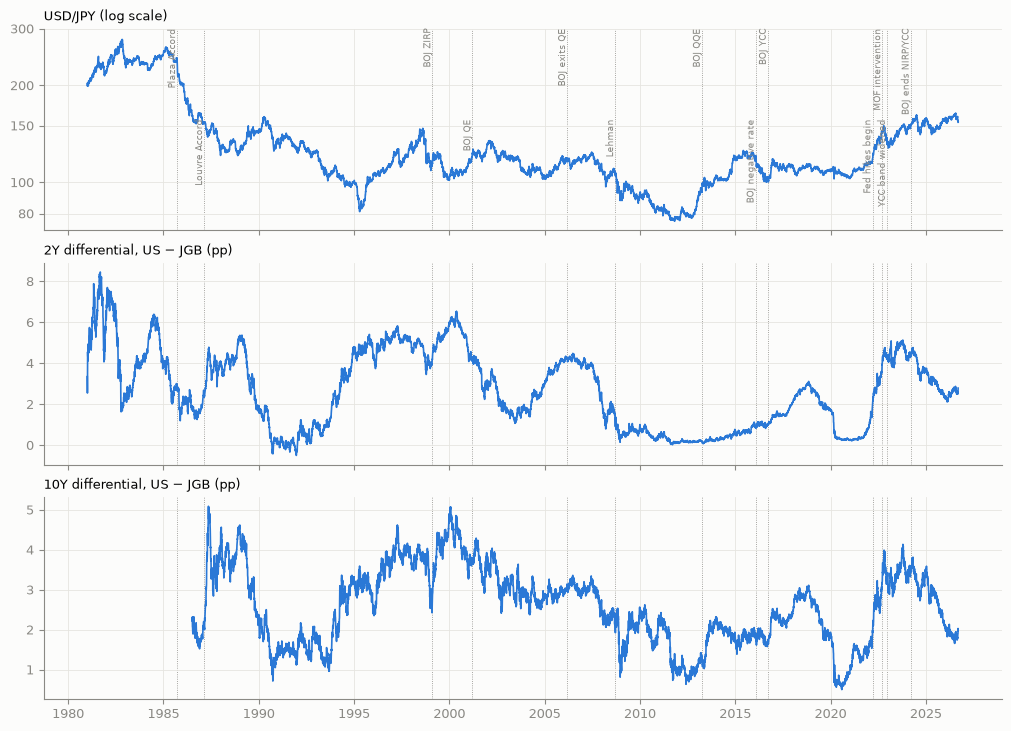

In [4]:
fig = ex.plot_levels(daily)
ex.save(fig, "01_levels")

**Notes.** Both differentials swing between about 0 and 8 pp (2Y) with long cycles; USD/JPY trends down from 250 to 80 (1981–2011) and back up to about 160. The 2Y differential sat near zero from 2009 to 2015 and again in 2020–21 (zero lower bound in both countries), so for long stretches it carried very little variation.

## 4. The two legs of each differential

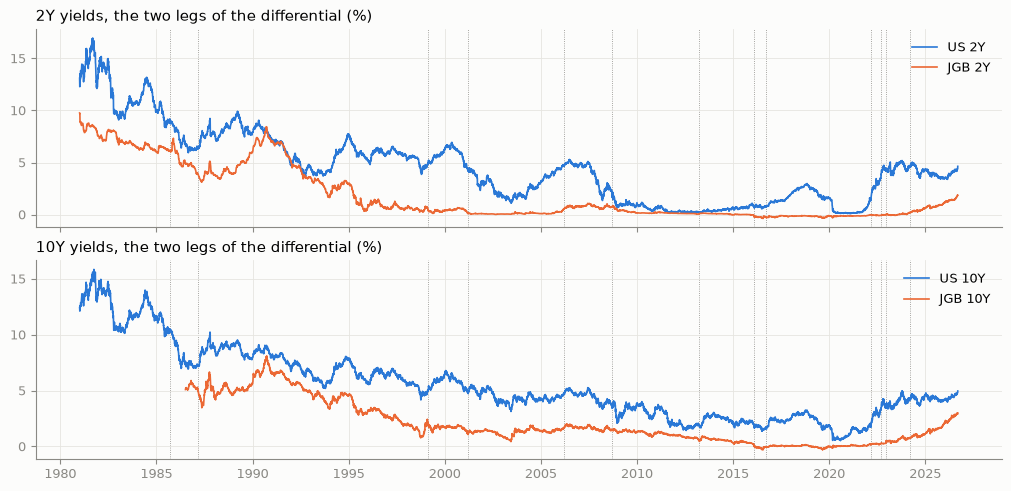

In [5]:
fig = ex.plot_legs(daily)
ex.save(fig, "02_legs")

**Notes.** From about 1999 to 2022 the JGB 2Y yield is pinned near zero, so the 2Y differential is essentially the US 2Y yield. Over that period "USD/JPY vs the differential" cannot be told apart from "USD/JPY vs US yields". Since 2024 the JGB leg moves again (2Y ≈ 1.8%, 10Y ≈ 3.0% in September 2026), so the recent narrowing of the differential comes from *both* legs. This matters for how H1 is worded and for any later decomposition.

## 5. Month-end USD/JPY against the 2Y differential, by era

Grey is the full sample; blue is the era. Eras are descriptive labels fixed in ADR 0004,
not estimated breaks.

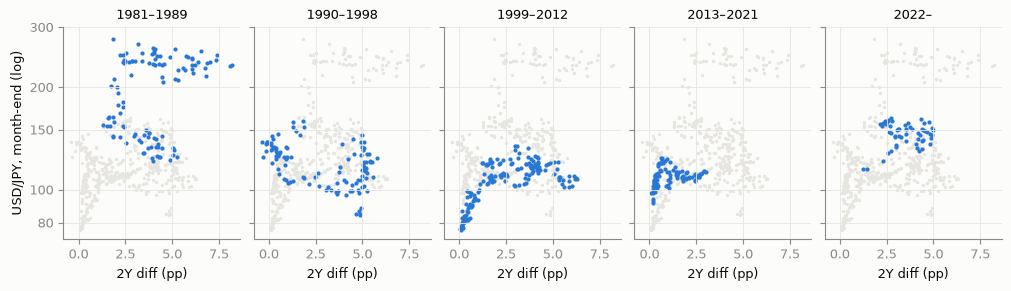

In [6]:
fig = ex.plot_scatter_by_era(monthly)
ex.save(fig, "03_scatter_by_era")

**Notes.** Each era occupies a different region, and within eras the slope is not the same (1990–1998 even slopes down). At a 2Y differential of about 2–2.6 pp, month-end USD/JPY was about 108 in June 2019 but about 160 in August 2026. This is the pattern behind the "decoupling" narrative in *levels*, but the scatter also shows that the level relationship was never one stable line in this sample: the 1980s cloud shifts vertically by roughly 100 yen (Plaza). Both points must be kept in view.

## 6. Stationarity diagnostics (month-end, from 1981)

ADF's null is a unit root (small p: reject, looks stationary). KPSS's null is stationarity
(small p: reject, looks non-stationary). Read together:

| ADF | KPSS | reading |
|---|---|---|
| does not reject | rejects | unit root likely |
| rejects | does not reject | stationary likely |
| both reject / neither rejects | | inconclusive |

These inform the later levels-versus-changes decision; they do not make it.

,series,form,n,adf_stat,adf_p,kpss_stat,kpss_p
0,log_usdjpy,level,548,-2.32,0.166,1.33,<0.01
1,log_usdjpy,change,547,-14.94,0.000,0.32,>0.10
2,diff_2y,level,548,-2.84,0.053,0.70,0.013
3,diff_2y,change,547,-20.37,0.000,0.05,>0.10
4,diff_10y,level,482,-2.88,0.047,0.64,0.019
5,diff_10y,change,481,-17.28,0.000,0.05,>0.10


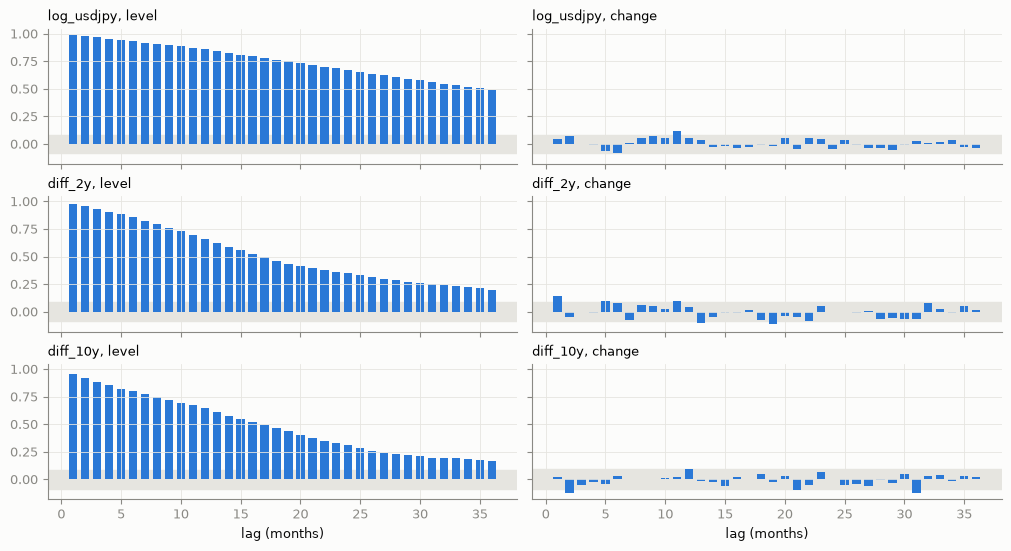

In [7]:
m = monthly[monthly["date"] >= "1981-01-01"].set_index("date")
series = {"log_usdjpy": np.log(m["usdjpy"]), "diff_2y": m["diff_2y"], "diff_10y": m["diff_10y"]}
display(ex.stationarity(series))
fig = ex.plot_acf(series)
ex.save(fig, "04_acf")

**Notes.** Log USD/JPY in levels: ADF does not reject (p = 0.17), KPSS rejects (p < 0.01) → unit root likely. The differentials in levels are borderline: ADF p ≈ 0.05, KPSS p ≈ 0.01–0.02, so both tests reject near 5% → inconclusive (consistent with a very persistent series, or a stationary series with breaks in its mean). All three in changes: ADF rejects strongly, KPSS does not reject → stationary. The ACFs agree: levels decay slowly over 36 months, changes are close to white noise.

**Implication (not a decision):** a regression of the FX level on the differential level is at risk of being spurious and is unbalanced if the differential is I(0) while FX is I(1). Changes are the safe baseline; any levels analysis needs a cointegration framework that allows for breaks.

## 7. Daily changes: distribution by era

`dfx` is the daily USD/JPY log change in %. `ddiff_2y` is the daily 2Y differential change
in pp, shown with every row and with the ADR 0004 exclusion applied.

dfx (all rows)


,n,mean,sd,skew,ex_kurt,max_abs
1981–1989,2258,-0.015,0.647,-0.332,2.597,3.475
1990–1998,2264,-0.011,0.727,-0.681,4.891,5.630
1999–2012,3521,-0.008,0.665,-0.348,3.904,5.216
2013–2021,2249,0.013,0.549,-0.099,4.554,3.498
2022–,1175,0.025,0.666,-0.687,3.747,4.322


ddiff_2y (all rows)


,n,mean,sd,skew,ex_kurt,max_abs
1981–1989,2258,-0.001,0.124,-0.099,7.641,0.890
1990–1998,2264,0.001,0.069,-0.096,2.133,0.405
1999–2012,3521,-0.001,0.060,-0.127,6.400,0.539
2013–2021,2247,0.000,0.031,-0.435,3.895,0.202
2022–,1175,0.002,0.072,-0.506,5.070,0.575


ddiff_2y (exclusion applied)


,n,mean,sd,skew,ex_kurt,max_abs
1981–1989,2038,-0.001,0.123,-0.096,7.191,0.890
1990–1998,2035,0.001,0.069,-0.111,1.972,0.405
1999–2012,3154,-0.001,0.059,0.196,4.362,0.414
2013–2021,2007,0.000,0.032,-0.473,3.834,0.202
2022–,1045,0.001,0.073,-0.577,5.282,0.575


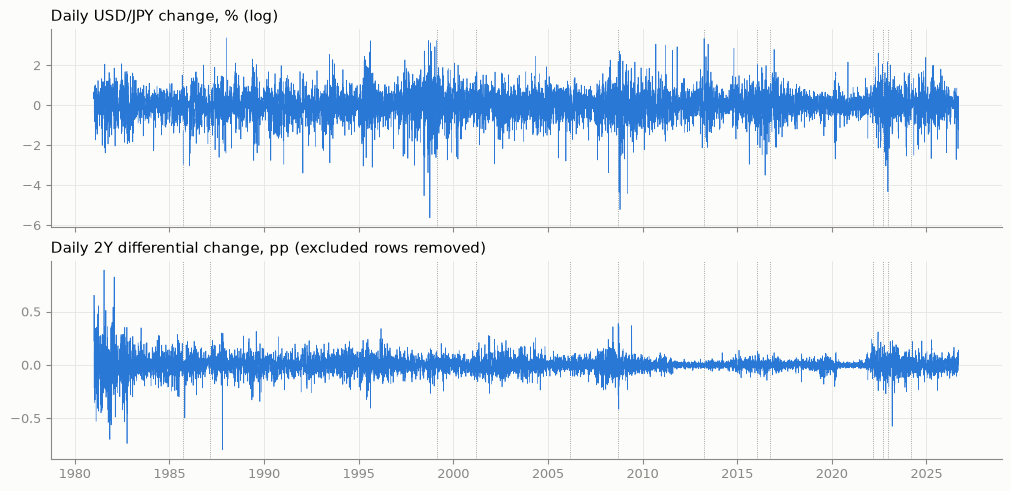

In [8]:
ch = ex.changes(daily, "2y", "same-day")
in_sample = daily["date"] >= "1981-01-01"
dates = daily.loc[in_sample, "date"]
for label, d, values in [
    ("dfx (all rows)", dates, ex.one_row_change(daily, "usdjpy")[in_sample]),
    ("ddiff_2y (all rows)", dates, ex.one_row_change(daily, "diff_2y")[in_sample]),
    ("ddiff_2y (exclusion applied)", ch["date"], ch["ddiff"]),
]:
    print(label)
    display(ex.era_stats(d.reset_index(drop=True), values.reset_index(drop=True)))
fig = ex.plot_changes(daily)
ex.save(fig, "05_changes")

**Notes.** Daily USD/JPY volatility is broadly stable (sd 0.55–0.73%) with fat tails (excess kurtosis 2.6–4.9) and negative skew in every era (sharp yen appreciations). Differential volatility varies a lot: sd 0.12 pp in the 1980s, 0.03 pp in 2013–2021 (both short rates near zero), 0.07 pp since 2022. Both series show volatility clustering. Implications: HAC or other heteroskedasticity-robust errors are required, and a *regression slope* and a *correlation* can move in opposite directions when one variable's volatility changes this much. The exclusion rule removes about 10% of rows and barely changes the distribution.

## 8. Year-on-year inflation, US and Japan

Descriptive, by reference month. A real-rate variable built later must use the
availability dating in `monthly.csv` (ADR 0003), not this.

,us_cpi,jp_cpi
1981–1989,4.67,1.95
1990–1998,3.10,1.38
1999–2012,2.48,-0.28
2013–2021,1.87,0.61
2022–,4.33,2.75


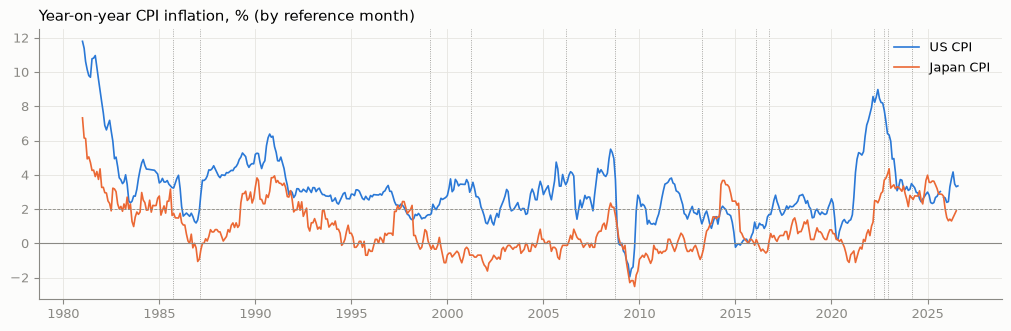

In [9]:
us_inf, jp_inf = ex.yoy(long, "us_cpi"), ex.yoy(long, "jp_cpi")
fig = ex.plot_inflation(us_inf, jp_inf)
ex.save(fig, "06_inflation")
both = pd.concat([us_inf, jp_inf], axis=1, sort=True).dropna()
both = both[both.index >= "1981-01-01"]
display(
    both.groupby(ex.era_of(both.index.to_series()).values).mean().reindex(list(ex.ERAS)).round(2)
)

**Notes.** Japan averaged about −0.3% inflation in 1999–2012 against about 2.5% in the US; since 2022 the averages are 2.75% and 4.33%. The visible Japanese spikes in 1989, 1997, 2014 and 2019 match the consumption-tax changes and are policy level shifts, not underlying inflation; a real-rate variable would need to handle them. The recent Japanese decline (to about 1.3–1.9% in 2026) has not been checked against the Statistics Bureau yet. The inflation gap narrowed from about 3 pp (1999–2012) to about 1.6 pp (2022–), so nominal and real differentials can tell different stories in exactly the period H1 is about.

## 9. Rolling correlation of daily FX and differential changes (frozen H1 view)

Eight series, exactly as specified in ADR 0004: {2Y primary, 10Y robustness} × {1y, 3y
window} × {same-day, lagged US leg}, with the change-carried exclusion. Bands are pointwise
95% Fisher-z intervals assuming independent rows: too narrow, descriptive only.

,maturity,timing,rows_with_differential,excluded,used
0,2y,same-day,11466,1187,10279
1,2y,lagged,11466,1190,10276
2,10y,same-day,10102,1067,9035
3,10y,lagged,10102,1070,9032


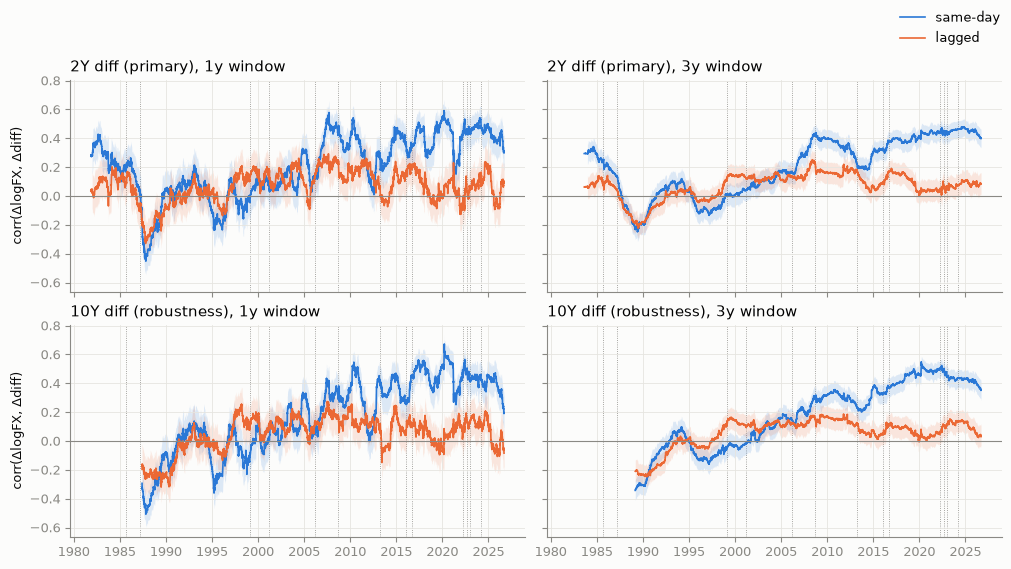

In [10]:
display(ex.exclusion_counts(daily))
h1 = ex.h1_rolling(daily)
fig = ex.plot_rolling(h1)
ex.save(fig, "07_rolling_corr")

In [11]:
# Mean rolling correlation by era, for reading the plot; not a test.
h1["era"] = ex.era_of(h1["date"]).values
by_era = h1.pivot_table(index="era", columns=["maturity", "window", "timing"], values="r")
by_era.reindex(list(ex.ERAS)).round(2)

maturity     10y                              2y                         
window        1y              3y              1y              3y         
timing    lagged same-day lagged same-day lagged same-day lagged same-day
era                                                                      
1981–1989  -0.23    -0.31  -0.22    -0.31  -0.01     0.08  -0.01     0.09
1990–1998  -0.01    -0.05  -0.06    -0.07   0.02    -0.00  -0.02    -0.02
1999–2012   0.13     0.18   0.13     0.16   0.15     0.22   0.15     0.21
2013–2021   0.06     0.42   0.06     0.39   0.07     0.37   0.09     0.35
2022–       0.08     0.42   0.10     0.44   0.06     0.44   0.07     0.45

**Notes on the frozen H1 view (exploratory, not a test).**

- **Same-day, 2Y (primary):** near zero or negative from about 1987 to 2004 (a dip to about −0.4 in 1987–88), rising after 2005, and between 0.2 and 0.6 since 2008. The latest values (2026-09-11) are 0.30 [0.17, 0.41] for the 1-year window and 0.40 [0.33, 0.46] for the 3-year window: lower than the 2020–2025 peak of about 0.45–0.5 (3y), but within the post-2008 range (1y minimum 0.01 in July 2012).
- **Lagged US leg:** close to zero throughout (about 0.0–0.2). Yesterday's US yield change says little about today's FX change beyond the ~3.5-hour overlap; the comovement is contemporaneous.
- **10Y (robustness):** same shape; the most recent 1-year value is lower (0.20).
- **Reading:** in *daily changes*, the data do not show the yen decoupling from the differential; if anything, comovement since 2008 is stronger than in 1987–2004. The recent 1-year decline is visible but is the size of earlier dips. Because the bands are too narrow (see ADR 0004), nothing here counts as evidence of a break.

## Summary for the next modeling decision

1. **"Decoupling" has two meanings that the data separate.** In daily *changes* the relationship is present and has been stronger since 2008. In *levels*, USD/JPY in 2024–2026 is far above where similar differentials put it in 2013–2021. H1 needs to state which one it tests (or both, as separate hypotheses) before any formal test is frozen.
2. **Levels vs changes.** Log USD/JPY behaves as I(1); the differentials are borderline. A changes regression (with HAC errors) is the safe baseline. A levels relationship needs a cointegration analysis that allows for breaks and must not be run as plain OLS.
3. **Which differential.** From 1999 to 2022 the 2Y differential is mostly the US yield. A later specification should consider the two legs separately as well as their difference.
4. **Correlation vs slope.** Differential volatility changed four-fold across eras, so rolling betas and rolling correlations must both be reported.
5. **Data issues to investigate** (none classified as errors): USD/JPY 1978-03-31 spike (pre-sample), JGB 2Y 1995-08-16, the 1987 JGB 10Y cluster, fed funds year-end spikes, and the 2026 Japan CPI decline.